## Notebook 1

This notebook illustrates the training of a very simple Neural Network to model a one dimensional data set.  The data is fictitiously generated from solving

$\frac{du}{dt}=-u^2$

with initial condition $u(0)=1.0$.  Training data is generated for $t\in[0,2]$. The intention is to try to use the Neural Network model to predict the solution for $t\in[0,5]$.  The Neural Network has one input, $t$ and one output $u(t)$.

---

Loading libraries

In [181]:
using OrdinaryDiffEq
using CairoMakie
using OrdinaryDiffEqTsit5
using LinearAlgebra
using Lux
using Random
using Optimization
using OptimizationOptimisers
using ComponentArrays
using Zygote

Parameters of the training and validation data set

In [182]:
#training parameters
max_iter=10_000
learning_rate=0.01

u0 = Float32[1.0]

# training data
datasize = 150
tspan = (0.0f0, 2.0f0)
tsteps = range(tspan[1], tspan[2]; length = datasize)

# validation data
tspan2 = (0.0f0, 5.0f0)
tsteps2 = range(tspan2[1], tspan2[2]; length = 200)

noise=0.002
random_initial_seed=3

3

Define governing equation

$\frac{du}{dt}=-u^2$


In [183]:
function trueODEfunc(du, u, p, t)
    du[1]=-u[1]*u[1]
end

trueODEfunc (generic function with 1 method)

Generating training data and add a bit of noise.  The training data is computed for $t\in[0,2]$

In [184]:
prob_trueode = ODEProblem(trueODEfunc, u0, tspan)
data = Array(solve(prob_trueode, Tsit5(); saveat = tsteps)) .+ noise*randn(length(u0), datasize)

1×150 Matrix{Float64}:
 1.00203  0.98782  0.970676  0.963313  …  0.335655  0.331689  0.335058

Generating the validation  data, for $t\in[0,5]$ 

In [185]:
#This is the prediction beyond the training data
prob_trueode_sol = ODEProblem(trueODEfunc, u0, tspan2)
data_true = Array(solve(prob_trueode_sol, Tsit5(); saveat = tsteps2)) 

1×200 Matrix{Float32}:
 1.0  0.97549  0.952153  0.929907  0.908676  …  0.168083  0.167376  0.166675

Plot the training and validation data to see how they look like. 

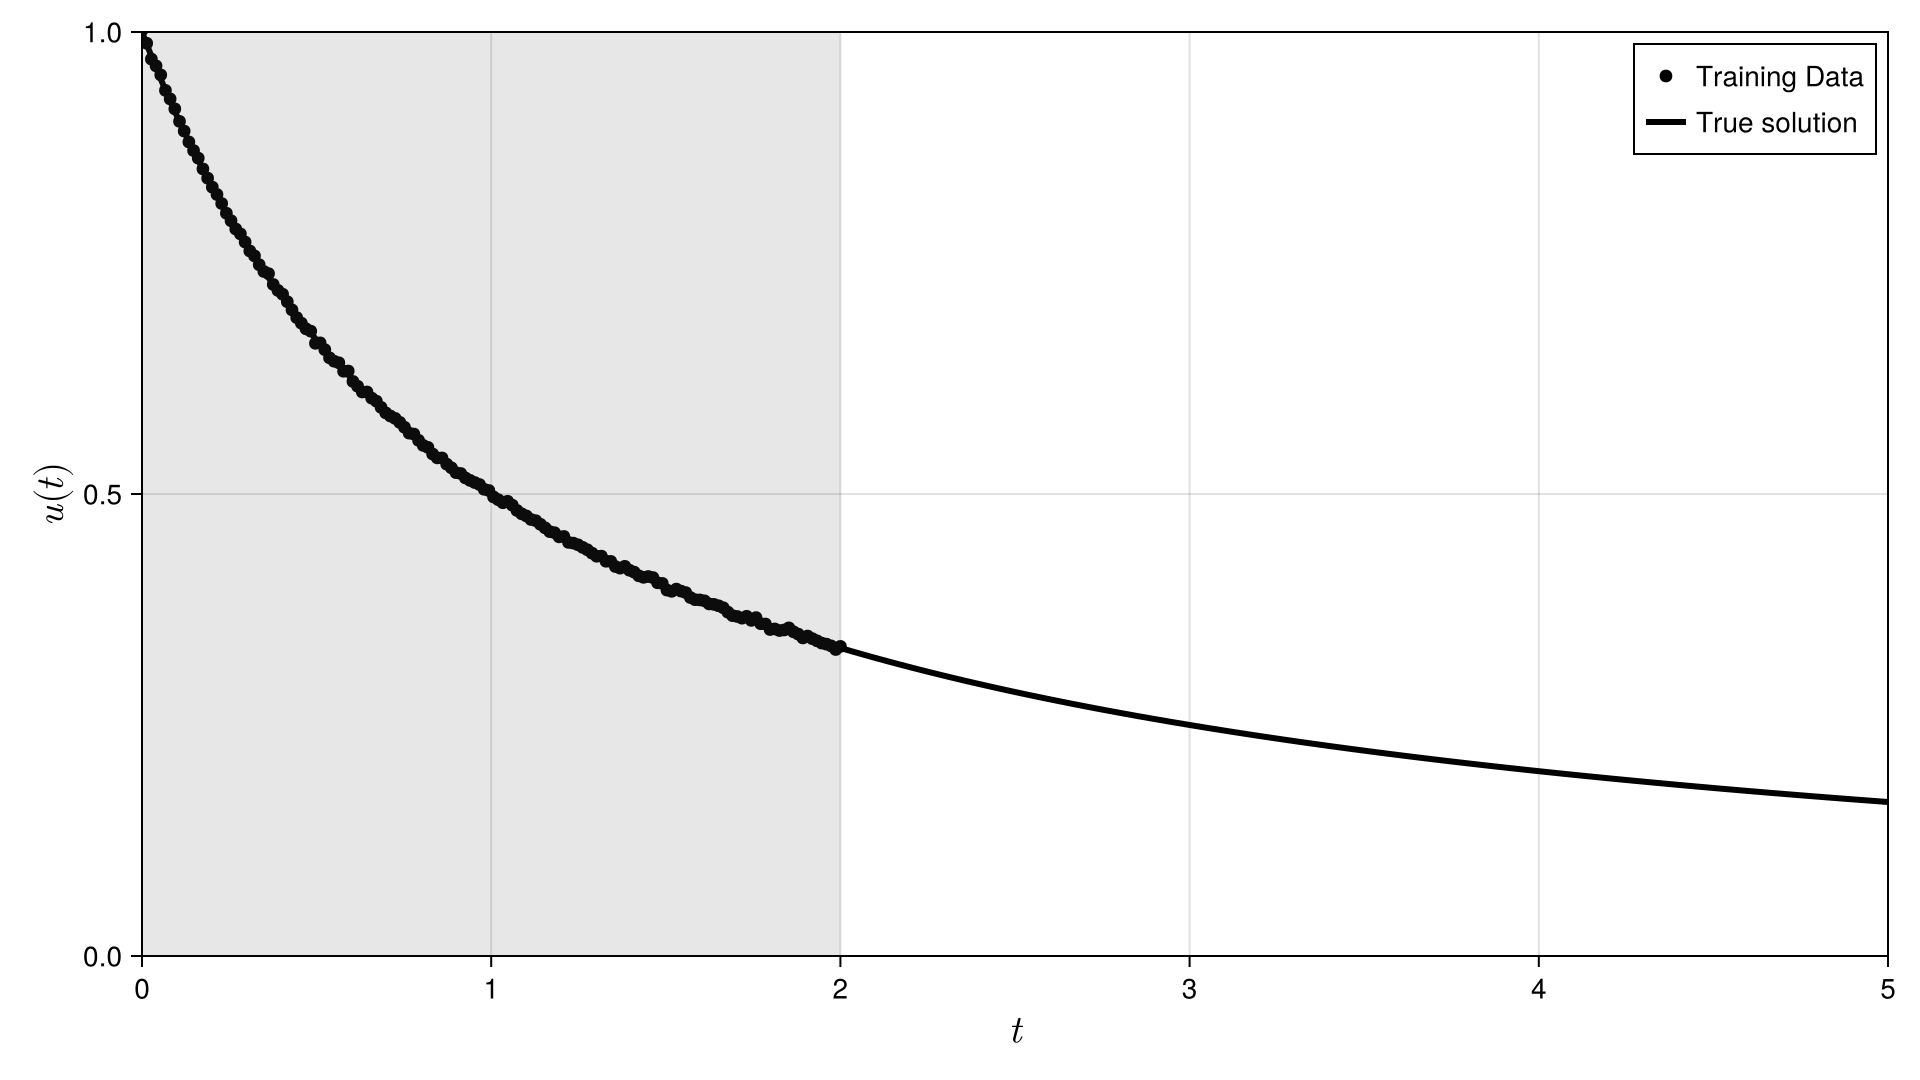

In [186]:
fig = CairoMakie.Figure(size = (960, 540),backgroundcolor = :transparent)
ax = CairoMakie.Axis(fig[1, 1],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"t",ylabel=L"u(t)",title="")
CairoMakie.scatter!(ax,tsteps, data[:];color=:black,label="Training Data")
CairoMakie.lines!(ax,tsteps2, data_true[:]; linewidth = 3,color=:black,label="True solution")
CairoMakie.vspan!(ax,tspan[1], tspan[2];color=(:grey, 0.1))
axislegend(ax;position=:rt)
xlims!(ax,tspan2[1],tspan2[2])
ylims!(ax,0,1)
save("figures/01_TrainingRegion.png", fig)
fig

Define Neural Network model,$NN(t;\vec{p})$.  One input layer and one output layer with one node.  Two hidden layers with 5 nodes and using the tanh activation function for the input and hidden layers.

In [187]:
rng = Xoshiro(random_initial_seed)
model = Chain(Dense(1, 5, tanh),
            Dense(5, 5, tanh),
             Dense(5, 1))
pinit, st = Lux.setup(rng, model)

((layer_1 = (weight = Float32[2.2234793; -0.9252919; … ; 2.651382; 2.5442355;;], bias = Float32[-0.7991946, -0.81577146, 0.578336, 0.3968519, 0.16445601]), layer_2 = (weight = Float32[-0.7375973 1.2798887 … -0.6285871 1.1732625; 0.39126006 -0.93281496 … -0.17190742 -0.29541454; … ; -1.0276101 0.02352893 … 0.4088462 0.524053; 0.45034525 0.9984187 … -0.4296156 -0.935433], bias = Float32[-0.42017847, 0.115000576, -0.37138525, -0.41014948, 0.013214716]), layer_3 = (weight = Float32[-0.5275636 0.21754348 … -0.7123893 -0.3478577], bias = Float32[-0.00041023595])), (layer_1 = NamedTuple(), layer_2 = NamedTuple(), layer_3 = NamedTuple()))

Plot the initial prediction of the Neural Network with the data 

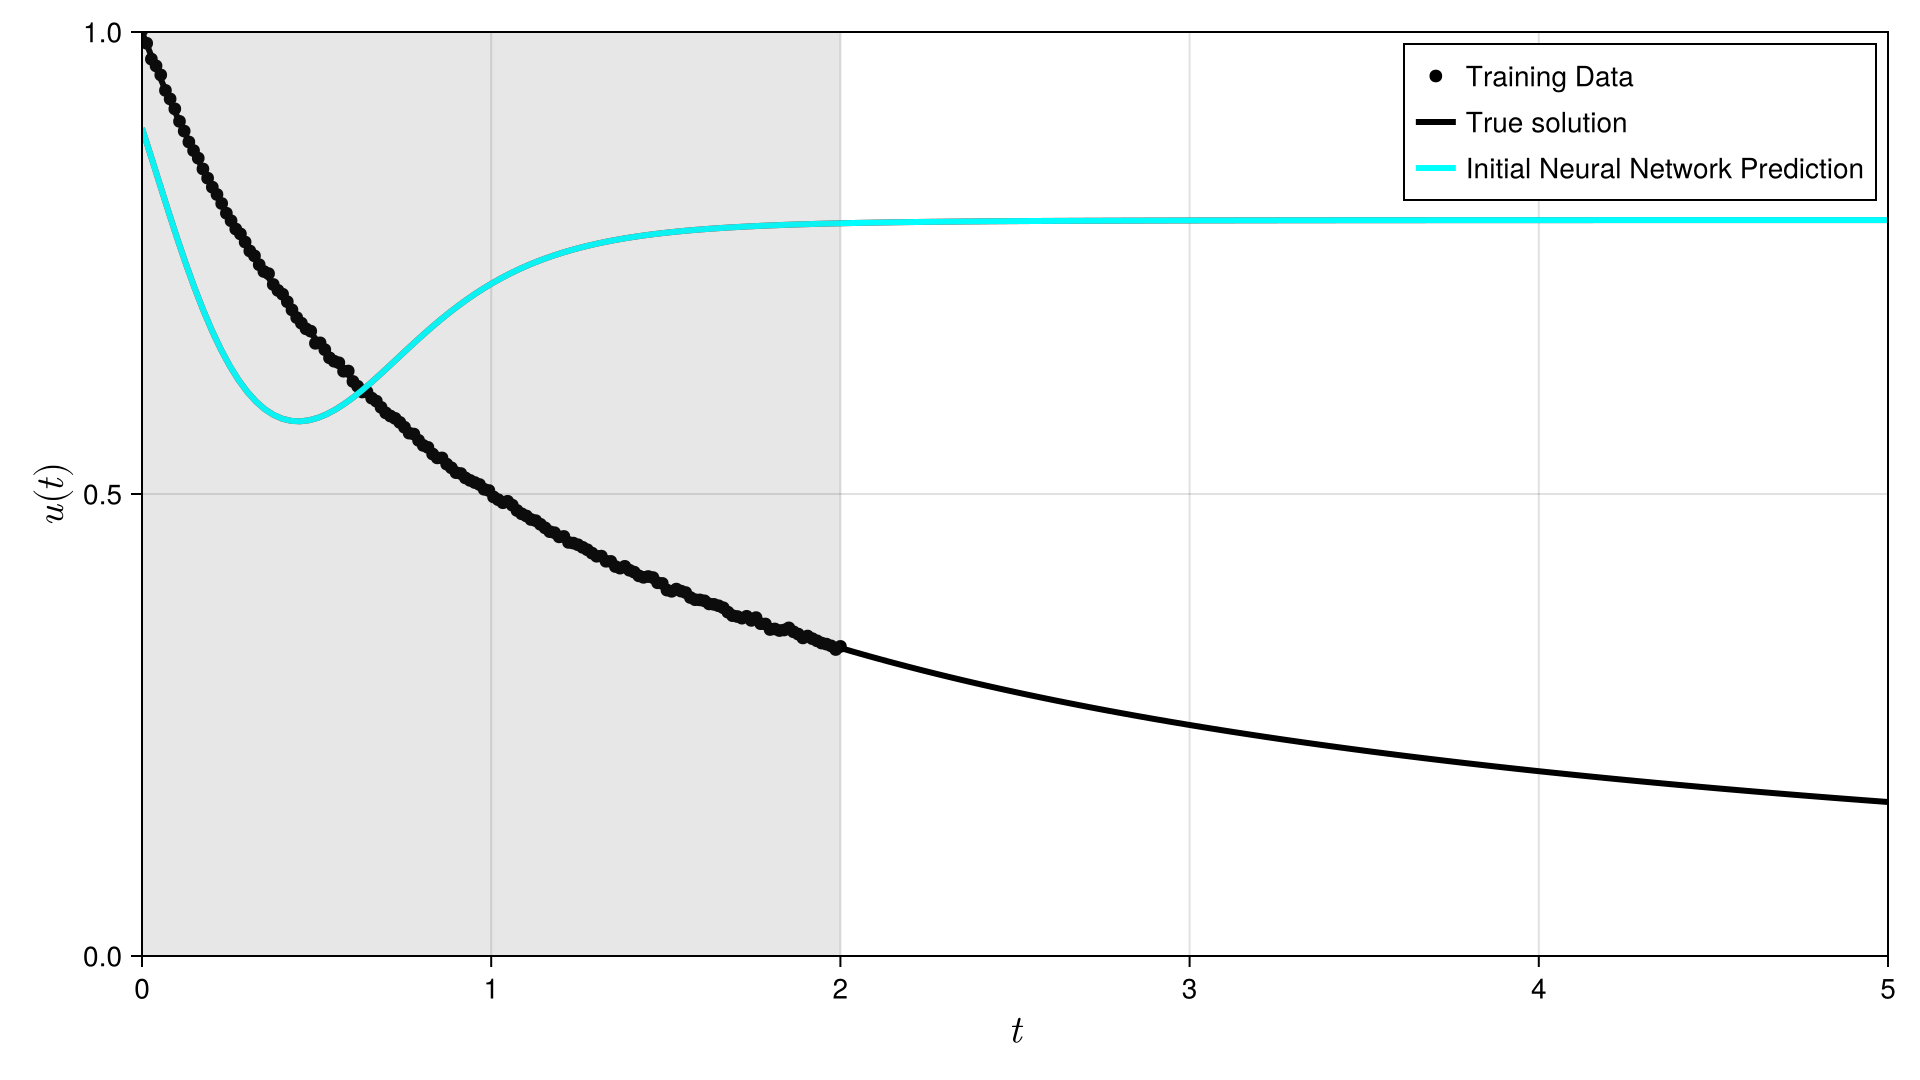

In [188]:
u_pred_init,_=model(Array(tsteps2)',pinit, st)

fig = CairoMakie.Figure(size = (960, 540),backgroundcolor = :transparent)
ax = CairoMakie.Axis(fig[1, 1],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"t",ylabel=L"u(t)",title="")
CairoMakie.scatter!(ax,tsteps, data[:];color=:black,label="Training Data")
CairoMakie.lines!(ax,tsteps2, data_true[:]; linewidth = 3,color=:black,label="True solution")
CairoMakie.lines!(ax,tsteps2, u_pred_init[:];linewidth = 3,color=:cyan,label="Initial Neural Network Prediction")
CairoMakie.vspan!(ax,tspan[1], tspan[2];color=(:grey, 0.1))
axislegend(ax;position=:rt)
xlims!(ax,tspan2[1],tspan2[2])
ylims!(ax,0,1)
save("figures/01_InitialNNPrediction.png", fig)
fig

As can be seen the prediction from the Neural Network is not good.  This is because the parameters of the Neural network has not been "trained" yet. 

To train the Neural Network we first need to define the loss function.

$\mathcal{L}(\vec{p})=\frac{1}{2}\frac{1}{N}\sum\limits_{i=1}^{N}(NN(t_i;\vec{p})-u_i)^2$

In [189]:
function loss(p,(data,tsteps))
    cost=0.0
    upred,_=model(Array(tsteps)', p, st)
    cost=0.5*sum((upred.-data).^2)/length(tsteps)
    return cost 
end

loss (generic function with 1 method)

In [190]:
# Initialize a vector to store loss values
loss_history = Float64[]

callback = function (p, l)
    if p.iter % 1000 == 0
        println("Iteration: $(p.iter), Loss: $l")
    end
    push!(loss_history, l)
    return false
end

adtype = Optimization.AutoZygote()
optf = Optimization.OptimizationFunction((p,x)->loss(p,(data,tsteps)), adtype)
optprob = Optimization.OptimizationProblem(optf,ComponentArray(pinit),(data,tsteps))
result = Optimization.solve(optprob, OptimizationOptimisers.Adam(learning_rate); callback=callback, epochs =max_iter)


Iteration: 1000, Loss: 2.233512439792116e-5
Iteration: 2000, Loss: 4.660501952205674e-6
Iteration: 3000, Loss: 3.4004639853738346e-6
Iteration: 4000, Loss: 0.00011982115287064494
Iteration: 5000, Loss: 2.7421076087320356e-6
Iteration: 6000, Loss: 2.589175060539913e-6
Iteration: 7000, Loss: 2.448303423880705e-6
Iteration: 8000, Loss: 2.342818987256798e-6
Iteration: 9000, Loss: 2.3290581875024416e-6
Iteration: 10000, Loss: 2.2258232992776107e-6
Iteration: 10000, Loss: 2.1870263856271287e-6


retcode: Default
u: ComponentVector{Float32}(layer_1 = (weight = Float32[1.5432181; -1.1038449; … ; 2.134889; 2.0053625;;], bias = Float32[-0.85435617, -1.2141664, 0.78827703, -1.1449878, 0.27454177]), layer_2 = (weight = Float32[-0.6701068 1.3827207 … -0.6392179 1.0058277; 0.12285368 -0.78419536 … -0.39641535 -0.47645026; … ; -0.7921326 -0.09190943 … 0.6398533 0.64830005; 0.89492863 1.3361418 … -0.11480305 -0.62740695], bias = Float32[-0.559567, 0.012119646, -0.6545556, -0.3364754, -0.45224008]), layer_3 = (weight = Float32[-0.4328092 0.048538208 … -0.6215549 -0.2888294], bias = Float32[-0.026798183]))

Plot the loss history

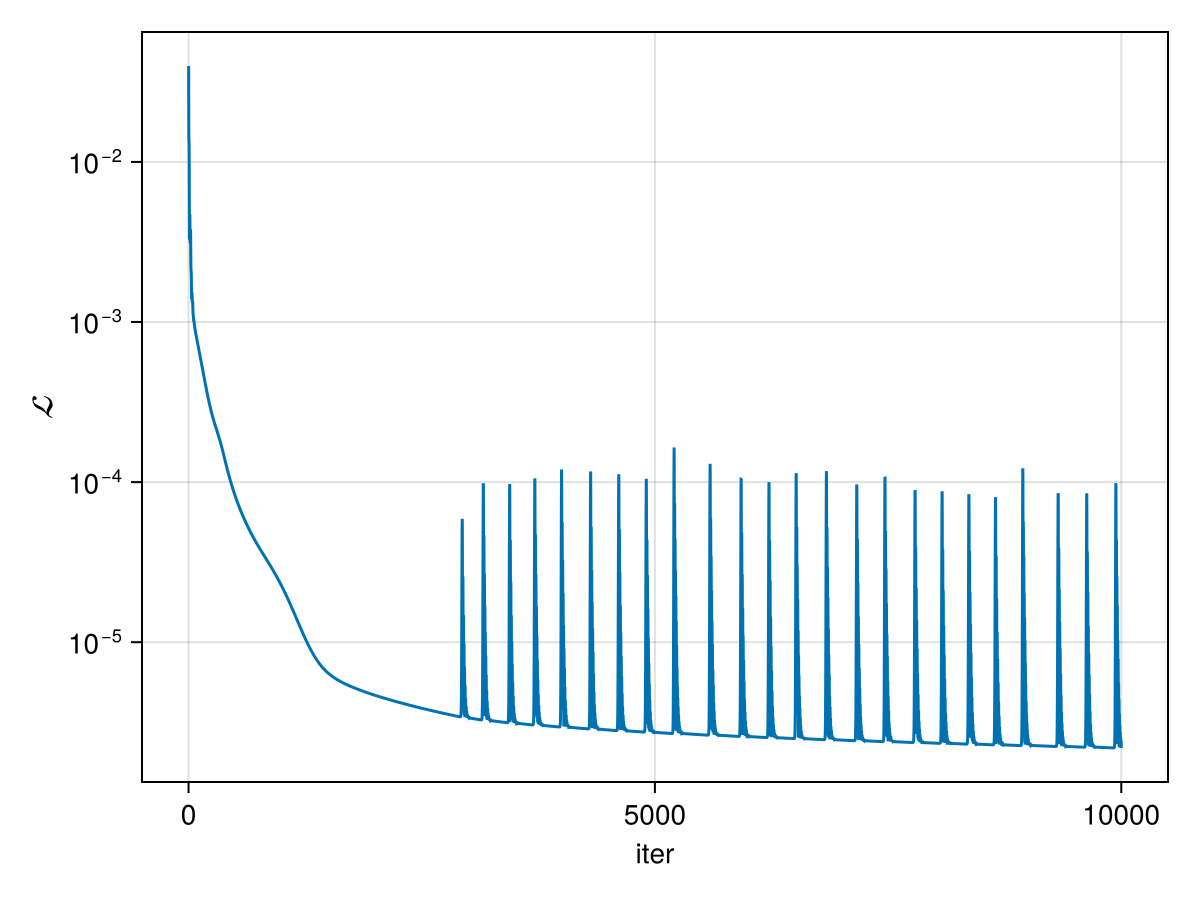

In [191]:
fig = CairoMakie.Figure()
ax = CairoMakie.Axis(fig[1, 1],yscale=log10,xlabel="iter",ylabel=L"\mathcal{L}")
CairoMakie.lines!(ax,loss_history)
fig

Using the model to predict the solution for $t\in[0,5]$.

In [192]:
u_pred,_=model(Array(tsteps2)',result.u, st)

(Float32[0.9971892 0.9755524 … 0.28509483 0.28508785], (layer_1 = NamedTuple(), layer_2 = NamedTuple(), layer_3 = NamedTuple()))

Visualise the outcomes of the training

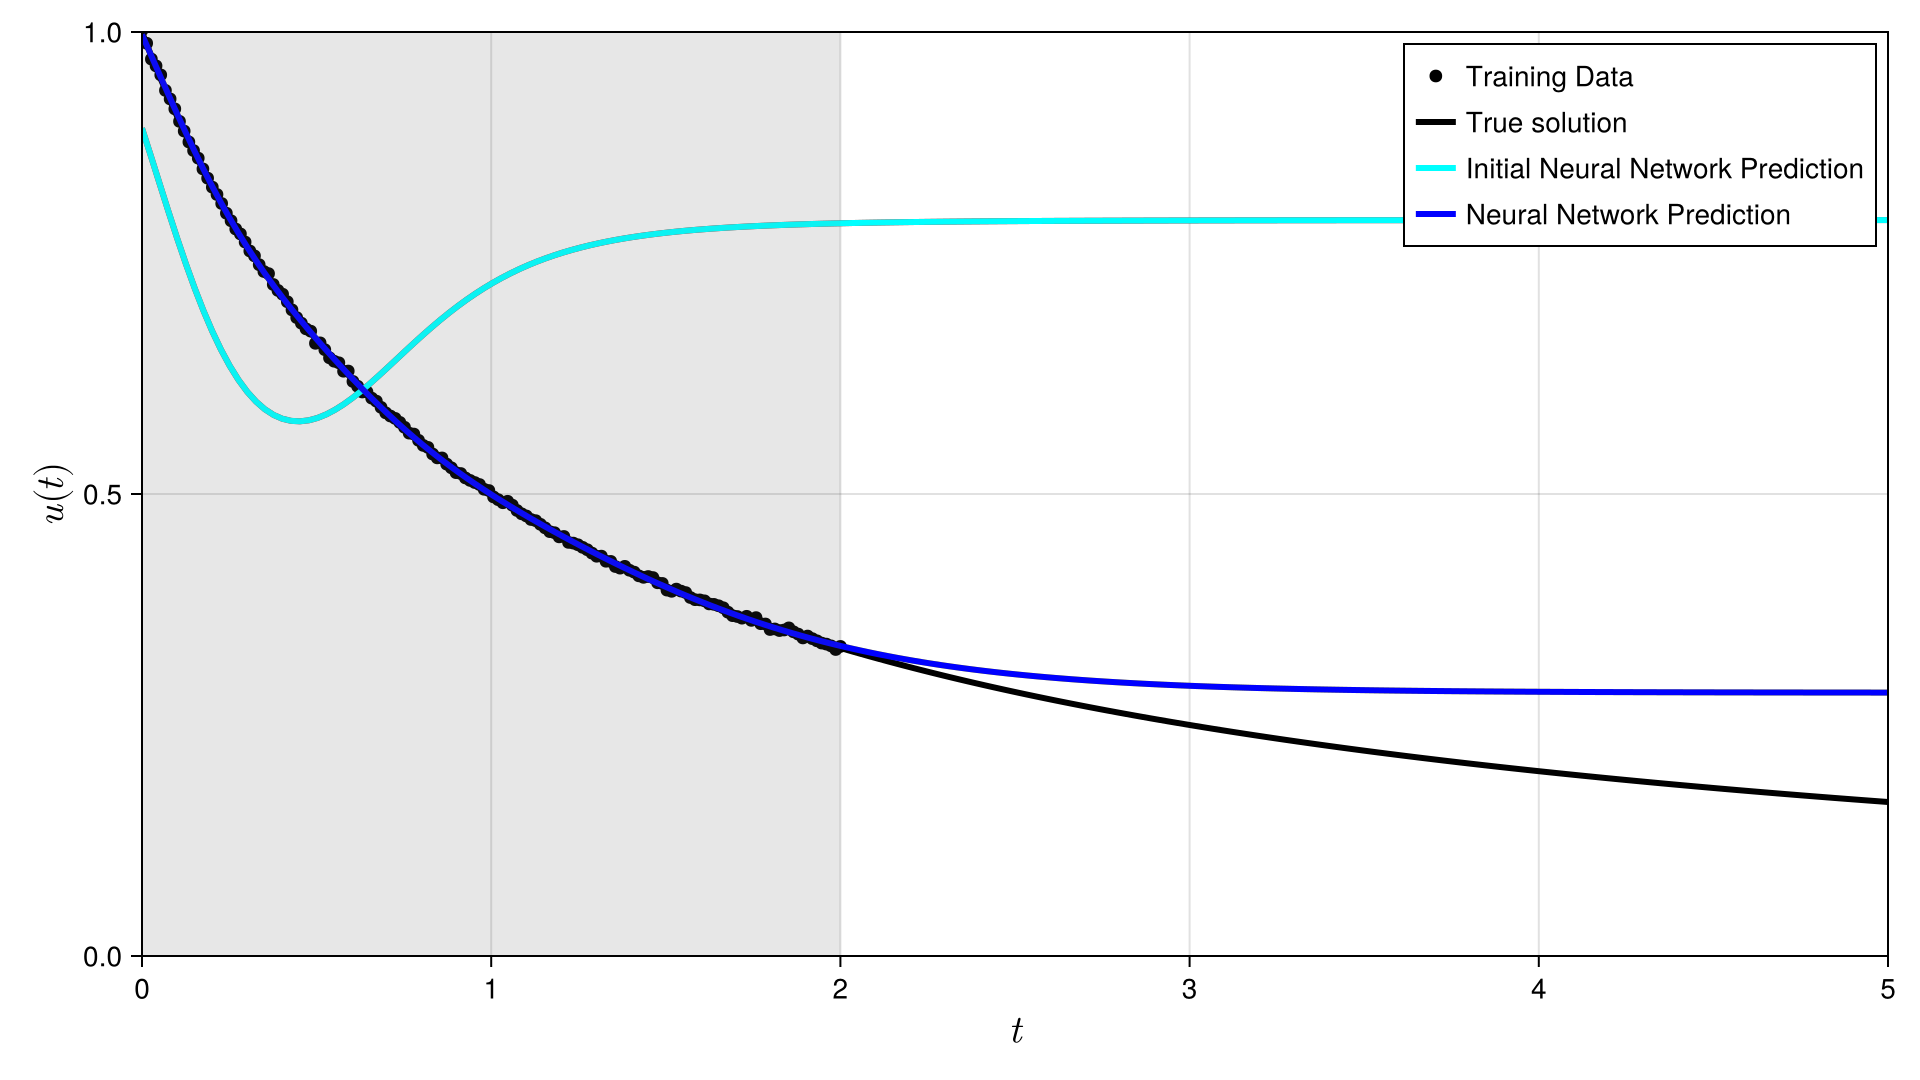

In [193]:
fig = CairoMakie.Figure(size = (960, 540),backgroundcolor = :transparent)
ax = CairoMakie.Axis(fig[1, 1],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"t",ylabel=L"u(t)",title="")
CairoMakie.scatter!(ax,tsteps, data[:];color=:black,label="Training Data")
CairoMakie.lines!(ax,tsteps2, data_true[:]; linewidth = 3,color=:black,label="True solution")
CairoMakie.lines!(ax,tsteps2, u_pred_init[:];linewidth = 3,color=:cyan,label="Initial Neural Network Prediction")
CairoMakie.lines!(ax,tsteps2, u_pred[:];linewidth = 3,color=:blue,label="Neural Network Prediction")
CairoMakie.vspan!(ax,tspan[1], tspan[2];color=(:grey, 0.1))
axislegend(ax;position=:rt)
xlims!(ax,tspan2[1],tspan2[2])
ylims!(ax,0,1)
save("figures/01_NeuralNetworkPrediction.png", fig)
fig

As you can see from the plot above the Neural Network model works pretty well in $t\in [0,2]$, where there is training data.  However, in regions where there is no training data, $t\in[2,5]$, the Neural Network model does not work very well. 

---
**Workshop Demo 01:**   Try changing the training time to $t\in [0,1]$.  What happens to the prediction solution for $t\in[1,5]$?  

---

---
**Workshop Demo 02:**   Rerun this example by setting the noise=0.01.  

---